In [1]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux
from few.utils.constants import Gpc, MRSUN_SI, YRSID_SI
from typing import Optional, Union, Callable
# from fastlisaresponse import ResponseWrapper
import tqdm
import os
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.fisher import StableEMRIFisher
try:
    import cupy as cp
    use_gpu = True
except ImportError:
    print("Not on GPU")
    use_gpu = False


use_gpu = False
if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info")
    force_backend = 'cpu'
else:
    force_backend = 'gpu'
    pass #let the backend decide for itself.

from few.waveform import (
    FastSchwarzschildEccentricFlux, 
    SlowSchwarzschildEccentricFlux, 
    Pn5AAKWaveform,
    FastKerrEccentricEquatorialFlux,
    GenerateEMRIWaveform,
)
##### SuperKludge Imports #####
from few.trajectory.ode.flux import SuperKludgeFlux
from few.waveform.waveform import SuperKludgeWaveform #waveform module
###############################
from pathlib import Path

startup
Not on GPU


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
waveform_class_kwargs = dict(inspiral_kwargs=dict(err=1e-11,),
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5))

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                      stats_for_nerds = True, use_gpu = use_gpu,
                      deriv_type='stable')

In [118]:
m1 = 1e6
m2 = 1e1
a = 0.8
e0 = 0.4
xI0 = 1.0
dist = 1
qS = 0.5
phiS = 1
qK = 1 #fixed
phiK = phiS + np.pi/3#FIXED
Phi_phi0 = 0.4#FIXED
Phi_theta0 =0.2
Phi_r0 = 0.5

dt = 10.0
T = 0.1

chi2 = 0.8

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=False
p0=9.0

pars_list_snr = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
              chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

#param_names = ['m1','m2','p0','e0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']
param_names = ['m1','m2','a','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0'] #works
#rhvae to take qK and phiK constant for it to run
#'Phi_phi0',"Phi_theta0",'Phi_r0' derivatives are present analytically it says

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev_0_p":dev_0_p,
"dev_0_e":dev_0_e,"dev_1_p":dev_1_p,"dev_1_e":dev_1_e,"dev_2_p":dev_2_p,"dev_2_e":dev_2_e}

emri_kwargs = {"T":T, "dt":dt}

sef.SNRcalc_SEF(*pars_list_snr,**emri_kwargs)


wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.8, 9.0, 0.4, 1.0, 1, 0.5, 1, 1, 2.0471975511965974, 0.4, 0.2, 0.5, 0.8, False, False, False, False, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)


np.float64(278.8729578937365)

T:  0.1 dt:  10.0
Body is not plunging, Fisher should be stable.
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.8, 9.0, 0.4, 1.0, 1, 0.5, 1, 1, 2.0471975511965974, 0.4, 0.2, 0.5, 0.8, False, False, False, False, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 278.8729578937365
calculating stable deltas...
Gamma_ii for m1: 65.40881085826399
Gamma_ii for m1: 65.40881085708504
Gamma_ii for m1: 65.40881085080721
Gamma_ii for m1: 65.40881086978152
Gamma_ii for m1: 65.40881086984086
Gamma_ii for m1: 65.40880948941248
Gamma_ii for m1: 65.40881209943898
Gamma_ii for m1: 65.40880194969517
[np.float64(1.8024279949131205e-11), np.float64(9.597835107981186e-11), np.float64(2.900879031695453e-10), np.float64(9.072864725942685e-13), np.float64(2.1104624858425374e-08), np.float64(3.99032854313303e-08), np.float64(1.551739750375814e-07)]
3


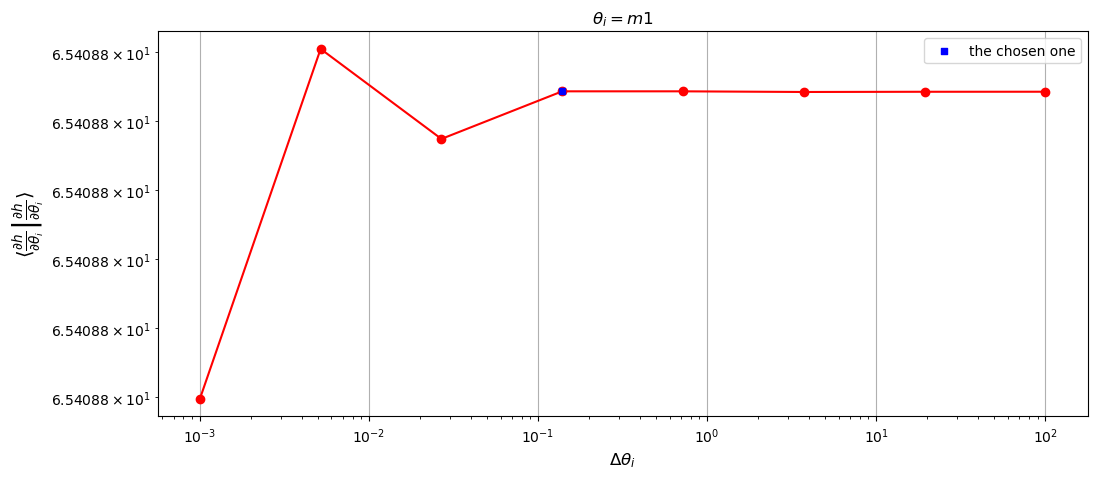

Gamma_ii for m2: 47358391.028482534
Gamma_ii for m2: 47358391.082345255
Gamma_ii for m2: 47358391.53624229
Gamma_ii for m2: 47358386.28353224
Gamma_ii for m2: 47358386.98621993
Gamma_ii for m2: 47358340.40868179
Gamma_ii for m2: 47358128.67706514
Gamma_ii for m2: 47357886.487969615
[np.float64(1.1373427073201402e-09), np.float64(9.584300097368738e-09), np.float64(1.109140421378988e-07), np.float64(1.483766092743673e-08), np.float64(9.835128878709498e-07), np.float64(4.470861129033377e-06), np.float64(5.11401824463719e-06)]
0


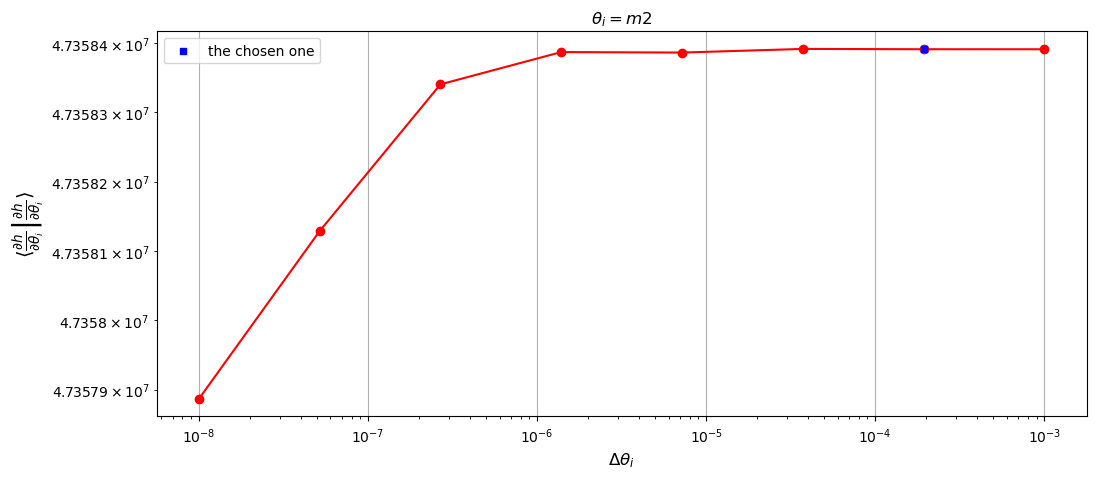

Gamma_ii for a: 242195933845.1214
Gamma_ii for a: 242196531245.5158
Gamma_ii for a: 242202733296.02917
Gamma_ii for a: 242146968223.79968
Gamma_ii for a: 242201782993.98065
Gamma_ii for a: 240896022535.53644
Gamma_ii for a: 236194659887.50952
Gamma_ii for a: 267267356902.88608
[np.float64(2.466593519473621e-06), np.float64(2.560685599607302e-05), np.float64(0.00023029432347859252), np.float64(0.0002263186071686827), np.float64(0.005420431789203124), np.float64(0.019904610249300285), np.float64(0.11626072624599304)]
0


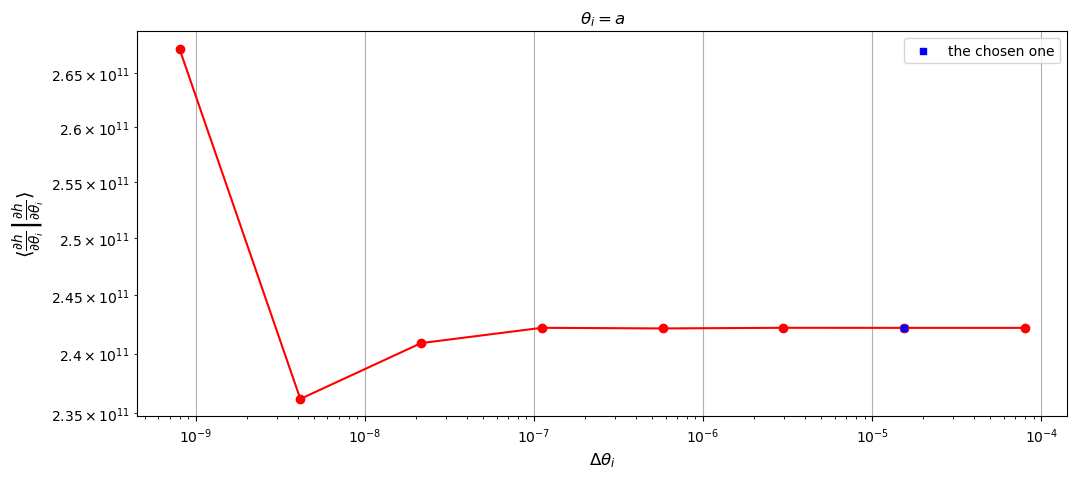

Gamma_ii for p0: 1671725620109.1433
Gamma_ii for p0: 1671724721805.8203
Gamma_ii for p0: 1671732892306.3657
Gamma_ii for p0: 1671743876802.3132
Gamma_ii for p0: 1671774942205.6958
Gamma_ii for p0: 1671957508012.1921
Gamma_ii for p0: 1669431420626.032
Gamma_ii for p0: 1666455445233.7368
[np.float64(5.373512225312354e-07), np.float64(4.887443791416895e-06), np.float64(6.570681131203391e-06), np.float64(1.8582287961309843e-05), np.float64(0.00010919285066843133), np.float64(0.0015131423519109761), np.float64(0.0017858115563826288)]
0


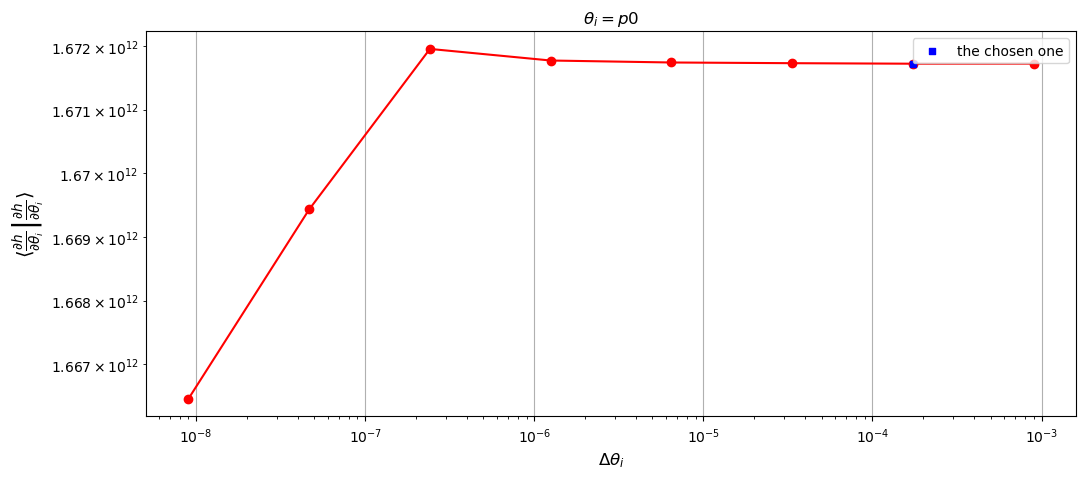

Gamma_ii for e0: 83572027943483.0
Gamma_ii for e0: 83572245415579.47
Gamma_ii for e0: 83572110478643.33
Gamma_ii for e0: 83567297920783.84
Gamma_ii for e0: 83568345083610.88
Gamma_ii for e0: 83689638218013.25
Gamma_ii for e0: 82990243924320.84
Gamma_ii for e0: 81831324777380.17
[np.float64(2.6022047796768788e-06), np.float64(1.6146168305167767e-06), np.float64(5.758900884944676e-05), np.float64(1.2530615820901494e-05), np.float64(0.001449320811811898), np.float64(0.008427427859233512), np.float64(0.01416229237512015)]
1


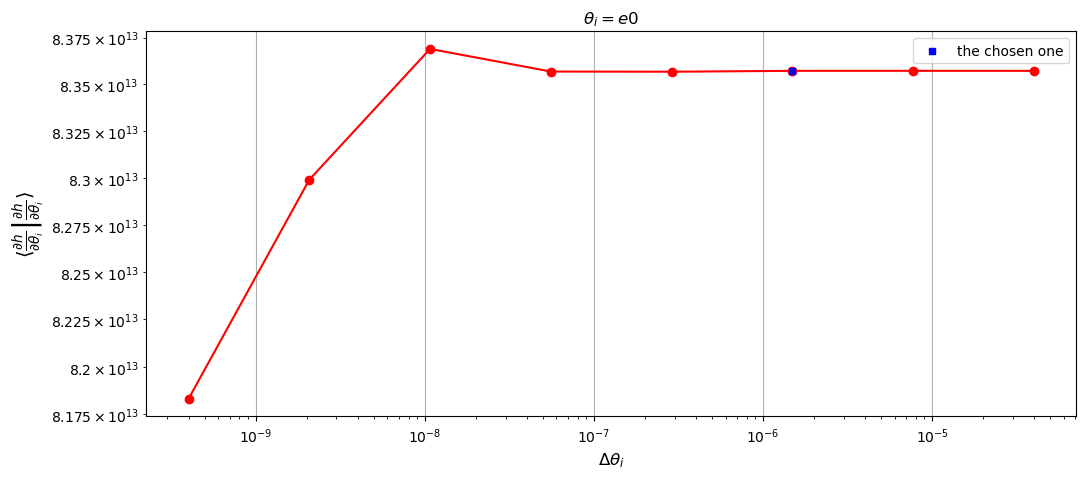

Gamma_ii for qS: 257691.61222031826
Gamma_ii for qS: 257691.61224252786
Gamma_ii for qS: 257691.61224252987
Gamma_ii for qS: 257691.61224252832
Gamma_ii for qS: 257691.6122425199
Gamma_ii for qS: 257691.61224249902
Gamma_ii for qS: 257691.61224313147
Gamma_ii for qS: 257691.61224221942
[np.float64(8.618673494858696e-11), np.float64(7.792897425099795e-15), np.float64(5.985848746815819e-15), np.float64(3.26398167515062e-14), np.float64(8.109130943800466e-14), np.float64(2.4543109267311343e-12), np.float64(3.5393307175082834e-12)]
2


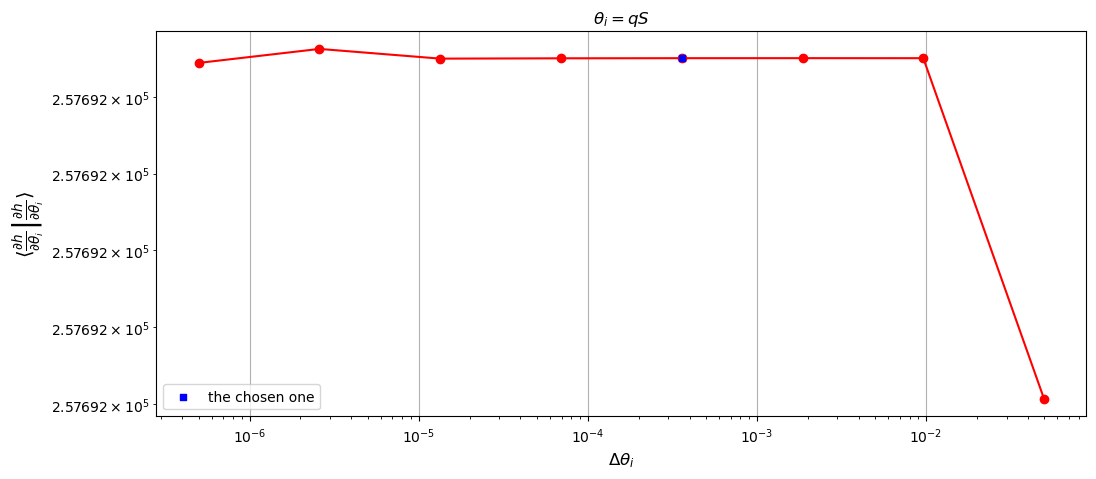

Gamma_ii for phiS: 291964.0699027443
Gamma_ii for phiS: 291964.0772636467
Gamma_ii for phiS: 291964.07726402744
Gamma_ii for phiS: 291964.0772640316
Gamma_ii for phiS: 291964.07726416166
Gamma_ii for phiS: 291964.0772643276
Gamma_ii for phiS: 291964.0772665507
Gamma_ii for phiS: 291964.07727701915
[np.float64(2.521167141878866e-08), np.float64(1.3040519011888055e-12), np.float64(1.4354339838800283e-14), np.float64(4.4538326666479933e-13), np.float64(5.683919844496962e-13), np.float64(7.614179821093478e-12), np.float64(3.5855346623248294e-11)]
2


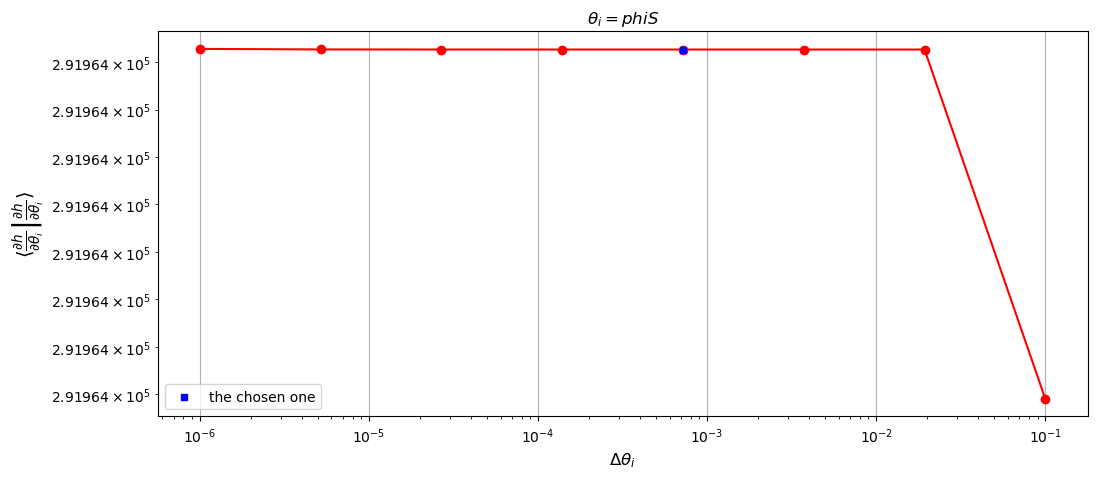

stable deltas: {'m1': 0.13894954943731375, 'm2': 0.00019306977288832496, 'a': 1.5445581831066e-05, 'p0': 0.00017376279559949242, 'e0': 1.4910374881259756e-06, 'dist': 0.0, 'qS': 0.00035984283650057603, 'phiS': 0.0007196856730011522, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 71.01078081130981 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 12.322359085083008 seconds


In [119]:
der_order = 6
Ndelta = 8
stability_plot = True

delta_range = dict(
    m1 = np.geomspace(1e-4*m1, 1e-9*m1, Ndelta),
    m2 = np.geomspace(1e-2*m2, 1e-7*m2, Ndelta),
    p0 = np.geomspace(1e-2*p0, 1e-7*p0, Ndelta),
    e0 = np.geomspace(1e-1*e0, 1e-7*e0, Ndelta),
    qS = np.geomspace(1e-4,    1e-9,    Ndelta),
    phiS = np.geomspace(1e-4,    1e-9,    Ndelta),
    # qK = np.geomspace(1e-4,    1e-9,    Ndelta),
    phiK = np.geomspace(1e-4,    1e-9,    Ndelta),
)

Fisher = sef(*pars_list,param_names = param_names,T = T, dt = dt, add_param_args=add_param_args,\
             der_order = der_order, Ndelta = Ndelta, stability_plot = stability_plot,
          #   delta_range = delta_range,
            live_dangerously = False)

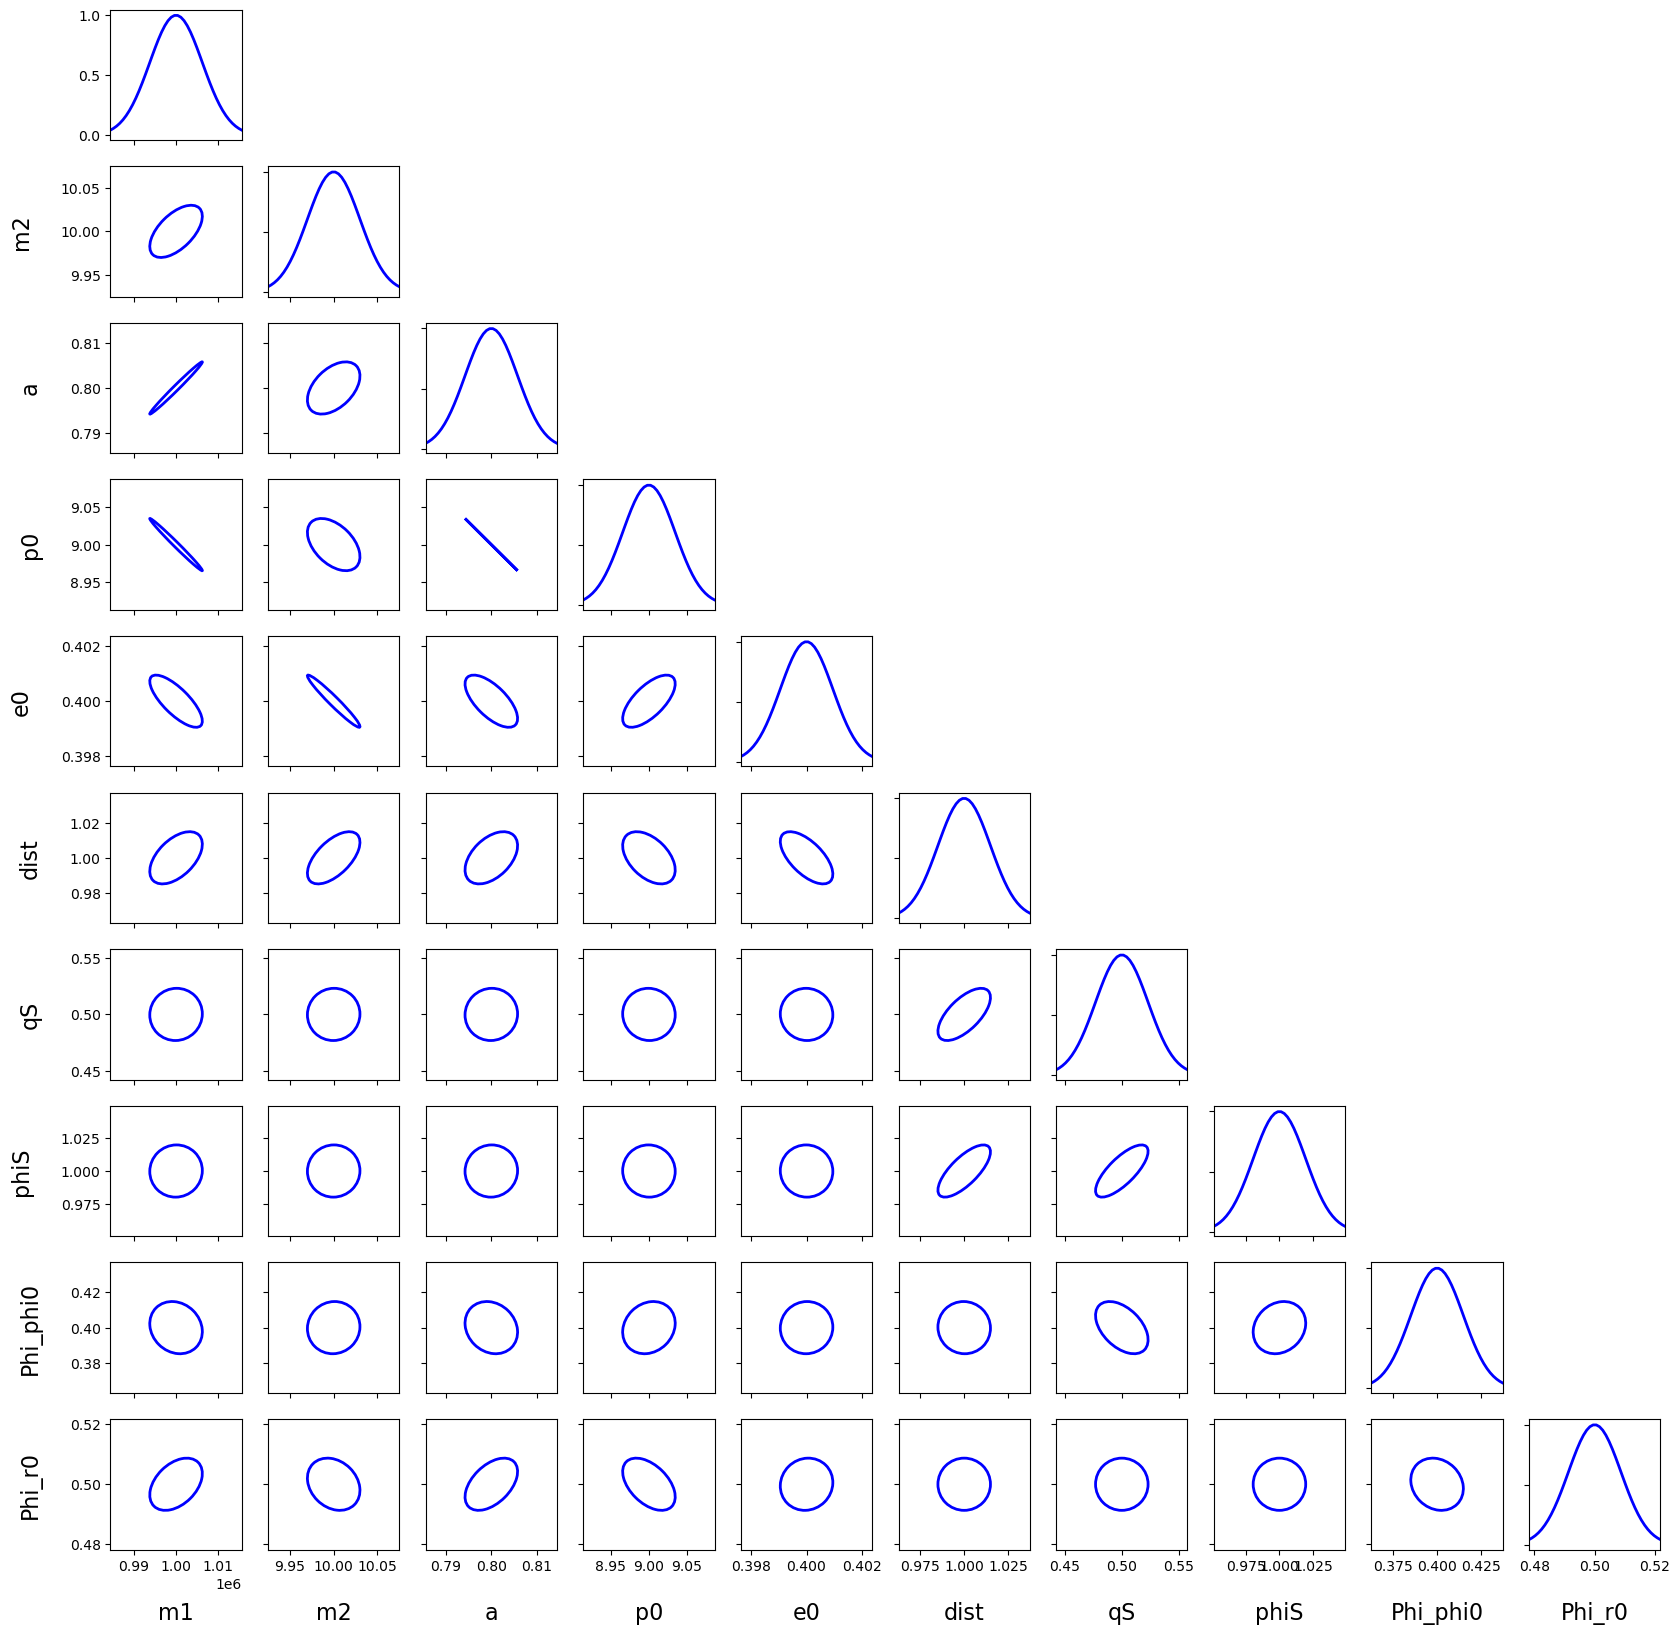

In [120]:

from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = [m1, m2, a,p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0]
param_names = ['m1','m2','a','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0']
wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = pars_list[i]
    
param_names = param_names

covariance = np.linalg.inv(Fisher)

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)



In [121]:
np.sqrt(covariance[5][5])

np.float64(0.014988379574626235)

In [122]:
np.savetxt("../../Results/Covariance_first_sampling_data.txt",covariance)

In [123]:
covariance.shape

(10, 10)